# Impatto dei conflitti di interesse

## Configurazione

In [443]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "analysis")
import analysis.utils as utils
RESULTS_ROOT = Path("results")
SCENARIOS_ROOT = Path("scenarios")
FIG_DIR = Path("analysis/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR = Path("analysis/tables");  TAB_DIR.mkdir(parents=True, exist_ok=True)

DENSITIES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
SCENARIOS = [f"conflicts-rho{round(d*100):03d}" for d in DENSITIES]
POINT_KEY = "conflict_density"

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "savefig.bbox": "tight"})


In [444]:
def band_plot(ax, stats, color, label=None, scale=1.0, marker="o"):
    x = stats.index.to_numpy()
    m = stats["mean"].to_numpy() * scale
    s = stats["std"].fillna(0).to_numpy() * scale
    ax.plot(x, m, marker=marker, color=color, label=label)
    ax.fill_between(x, m - s, m + s, color=color, alpha=0.18, linewidth=0)


def set_rho_x(ax):
    ax.set_xticks(DENSITIES)
    ax.set_xticklabels([f"{d:g}" for d in DENSITIES])
    ax.set_xlabel(r"Densità di conflitto $\rho$")


## Caricamento dei dati

In [445]:
tasks, nodes, runs = utils.load_scenarios(RESULTS_ROOT, SCENARIOS, POINT_KEY)

print(f"task totali: {len(tasks)}  |  run: {runs['replica'].count()}  "
      f"|  densità: {sorted(tasks['point'].unique())}")
runs.groupby("point")["replica"].nunique().rename("repliche")


task totali: 8000  |  run: 40  |  densità: [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8)]


point
0.1    5
0.2    5
0.3    5
0.4    5
0.5    5
0.6    5
0.7    5
0.8    5
Name: repliche, dtype: int64

## 0. Controlli di sanità

In [446]:
checks = []
for point, g in tasks.groupby("point"):
    checks.append(
        {
            "densità": point,
            "repliche": g["replica"].nunique(),
            "task": len(g),
            "ammessi_ok": bool(g["admitted"].sum() == len(g)),
            "rifiuti_other": int(g["n_attempts_other"].sum()),
            "timeout": int(g["timed_out"].sum()),
            "execution_mediana": round(g["execution_s"].median(), 2),
        }
    )
display(pd.DataFrame(checks).set_index("densità"))


,repliche,task,ammessi_ok,rifiuti_other,timeout,execution_mediana
densità,,,,,,
0.1,5,1000,True,0,0,21.23
0.2,5,1000,True,0,0,21.24
0.3,5,1000,True,0,0,21.26
0.4,5,1000,True,0,0,21.26
0.5,5,1000,True,0,0,21.26
0.6,5,1000,True,0,0,21.26
0.7,5,1000,True,0,0,21.26
0.8,5,1000,True,0,0,21.26


## 1. Parametri dell'esperimento

In [447]:
r0 = runs.iloc[0]
K = int(tasks["context"].str.extract(r"(\d+)").astype(int).max().iloc[0])
max_pairs = K * (K - 1) // 2
params = pd.DataFrame({
    "Parametro": ["Contesti $K$", "Intervallo di sanificazione", "Task per run $N$",
                  "Rate di sottomissione", "Durata task", "Nodi worker", "Repliche",
                  "Densità valutate"],
    "Valore": [
        K,
        f"{r0['sanitize_interval_seconds']:g}s",
        int(r0["tasks"]),
        f"1 ogni {r0['rate_seconds']:g}s",
        f"{r0['task_duration_seconds']:g}s",
        nodes["node"].nunique() if not nodes.empty else "n/d",
        int(runs.groupby("point")["replica"].nunique().max()),
        ", ".join(f"{d:g}" for d in DENSITIES),
    ],
}).set_index("Parametro")
display(params)
params.to_latex(TAB_DIR / "conflicts_parametri.tex", escape=False)

grid = pd.DataFrame({
    "densità": DENSITIES,
    "coppie": [int(np.ceil(d * max_pairs)) for d in DENSITIES],
    "grado medio": [round(2 * np.ceil(d * max_pairs) / K, 2) for d in DENSITIES],
}).set_index("densità")
display(grid)


,Valore
Parametro,
Contesti $K$,10
Intervallo di sanificazione,20s
Task per run $N$,200
Rate di sottomissione,1 ogni 1s
Durata task,20s
Nodi worker,5
Repliche,5
Densità valutate,"0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8"


,coppie,grado medio
densità,,
0.1,5,1.0
0.2,9,1.8
0.3,14,2.8
0.4,18,3.6
0.5,23,4.6
0.6,27,5.4
0.7,32,6.4
0.8,36,7.2


## 2. Curva principale: latenza di scheduling

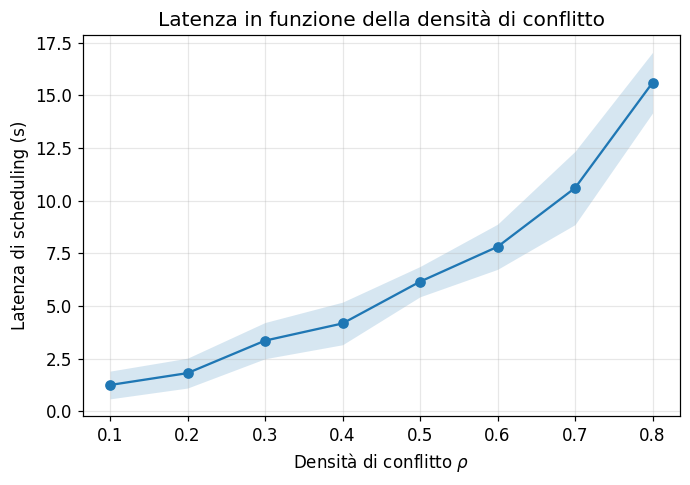

Latenza di base t0 (rho=0) = nans


In [448]:
lat = utils.per_point_stat(tasks, "latency_s", "mean")
p95 = utils.per_point_stat(tasks, "latency_s", lambda s: np.percentile(s, 95))

fig, ax = plt.subplots(figsize=(7, 4.5))
band_plot(ax, lat, "#1f77b4")
set_rho_x(ax)
ax.set_ylabel("Latenza di scheduling (s)")
ax.set_title("Latenza in funzione della densità di conflitto")
fig.savefig(FIG_DIR / "conflicts_latenza.pdf")
plt.show()

t0 = lat.loc[0, "mean"] if 0 in lat.index else np.nan
print(f"Latenza di base t0 (rho=0) = {t0:.3f}s")


## 3. Frazione di task bloccati

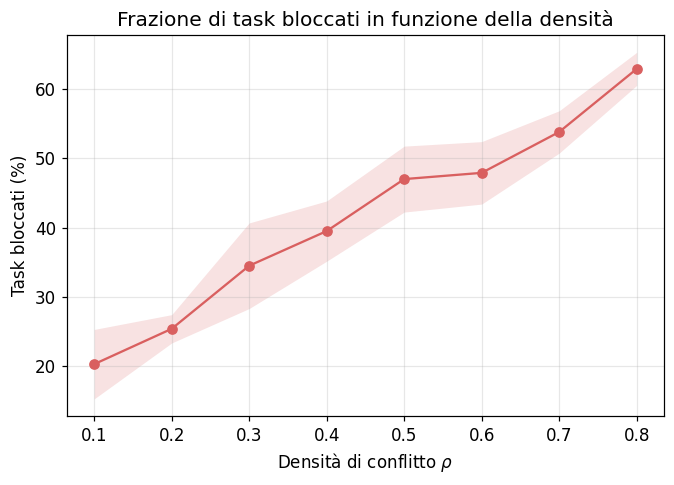

In [449]:
blocked = utils.per_point_stat(tasks.assign(b=tasks["blocked"].astype(float)), "b", "mean")

fig, ax = plt.subplots(figsize=(7, 4.5))
band_plot(ax, blocked, "#d95f5f", scale=100)
set_rho_x(ax)
ax.set_ylabel("Task bloccati (%)")
ax.set_title("Frazione di task bloccati in funzione della densità")
fig.savefig(FIG_DIR / "conflicts_bloccati.pdf")
plt.show()


## 4. Ripartizione per causa di blocco e attesa

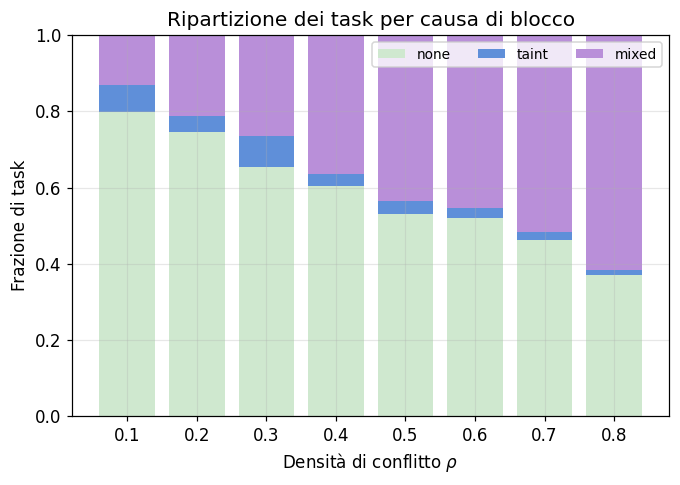

In [450]:
frac = utils.block_fraction_by_cause(tasks)
order = [c for c in ["none", "wall", "taint", "mixed", "other"] if c in frac.columns]
frac = frac[order]
colori = {"none": "#cfe8cf", "wall": "#d95f5f", "taint": "#5f8fd9", "mixed": "#b98fd9", "other": "#999999"}
x = np.arange(len(frac))
bottom = np.zeros(len(frac))
fig, ax = plt.subplots(figsize=(7, 4.5))
for c in order:
    ax.bar(x, frac[c].values, bottom=bottom, label=c, color=colori.get(c))
    bottom += frac[c].values
ax.set_xticks(x)
ax.set_xticklabels([f"{d:g}" for d in frac.index])
ax.set_ylim(0, 1)
ax.set_xlabel(r"Densità di conflitto $\rho$")
ax.set_ylabel("Frazione di task")
ax.set_title("Ripartizione dei task per causa di blocco")
ax.legend(ncol=len(order), fontsize=9, loc="upper right")
fig.savefig(FIG_DIR / "conflicts_cause_blocco.pdf")
plt.show()


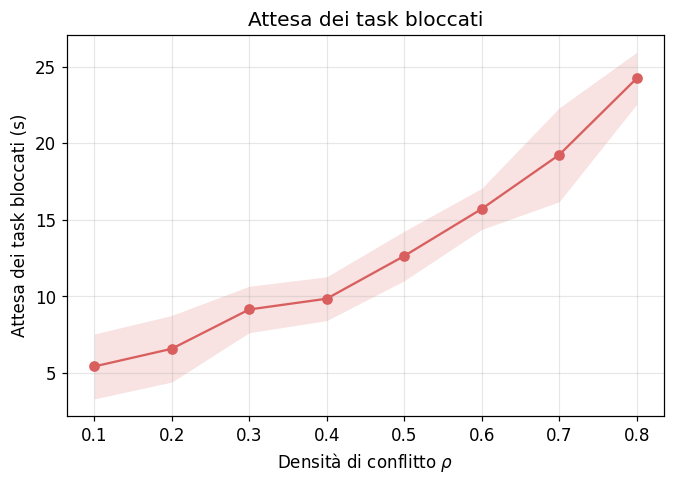

In [451]:
wait = utils.per_point_stat(tasks[tasks["blocked"]], "wait_s", "mean")
fig, ax = plt.subplots(figsize=(7, 4.5))
band_plot(ax, wait, "#d95f5f")
set_rho_x(ax)
ax.set_ylabel("Attesa dei task bloccati (s)")
ax.set_title("Attesa dei task bloccati")
fig.savefig(FIG_DIR / "conflicts_attesa.pdf")
plt.show()


## 5. Blocco in funzione del grado del contesto

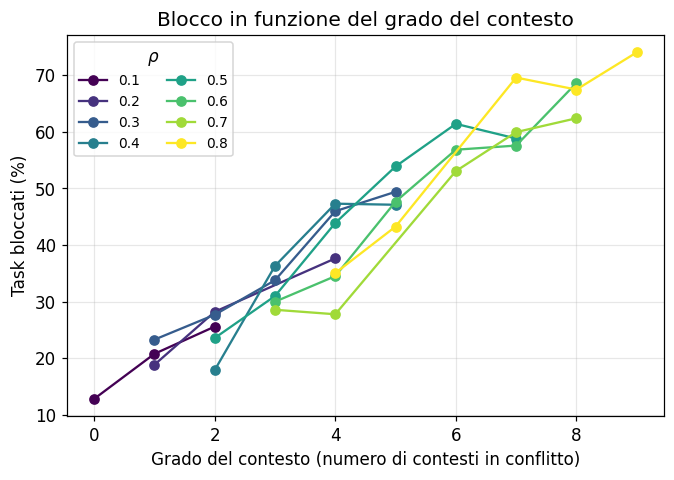

In [452]:
# Per ogni densità e grado del contesto, frazione di task bloccati (repliche unite).
deg = (
    tasks.groupby(["point", "context_degree"])["blocked"]
    .mean()
    .reset_index()
)
fig, ax = plt.subplots(figsize=(7, 4.5))
cmap = plt.get_cmap("viridis")
for k, point in enumerate(DENSITIES):
    sub = deg[deg["point"] == point].sort_values("context_degree")
    if sub.empty:
        continue
    ax.plot(sub["context_degree"], sub["blocked"] * 100, marker="o",
            color=cmap(k / max(1, len(DENSITIES) - 1)), label=f"{point:g}")
ax.set_xlabel("Grado del contesto (numero di contesti in conflitto)")
ax.set_ylabel("Task bloccati (%)")
ax.set_title("Blocco in funzione del grado del contesto")
ax.legend(title=r"$\rho$", ncol=2, fontsize=9)
fig.savefig(FIG_DIR / "conflicts_grado.pdf")
plt.show()


## 6. Distribuzione cumulata della latenza

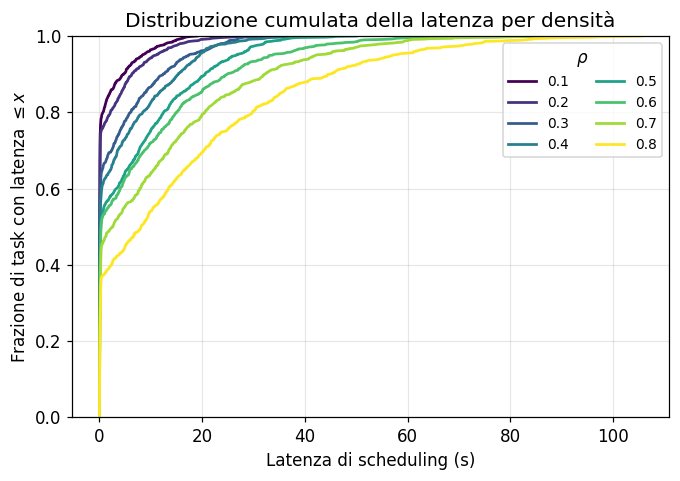

In [453]:
cmap = plt.get_cmap("viridis")
fig, ax = plt.subplots(figsize=(7, 4.5))
for k, point in enumerate(DENSITIES):
    x, y = utils.ecdf(tasks[tasks["point"] == point]["latency_s"])
    ax.plot(x, y, ls="-", lw=1.8, color=cmap(k / max(1, len(DENSITIES) - 1)), label=f"{point:g}")
ax.set_xlabel("Latenza di scheduling (s)")
ax.set_ylabel(r"Frazione di task con latenza $\leq x$")
ax.set_ylim(0, 1)
ax.set_title("Distribuzione cumulata della latenza per densità")
ax.legend(title=r"$\rho$", ncol=2, fontsize=9)
fig.savefig(FIG_DIR / "conflicts_cdf.pdf")
plt.show()


## 7. Makespan

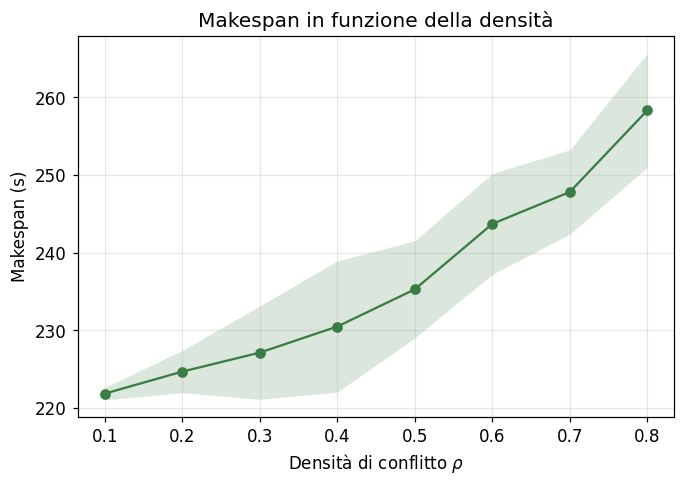

In [454]:
mk = runs.groupby("point")["makespan_s"].agg(["mean", "std"]).sort_index()
fig, ax = plt.subplots(figsize=(7, 4.5))
band_plot(ax, mk, "#3a7d44")
set_rho_x(ax)
ax.set_ylabel("Makespan (s)")
ax.set_title("Makespan in funzione della densità")
fig.savefig(FIG_DIR / "conflicts_makespan.pdf")
plt.show()


## 8. Tabella riassuntiva

In [455]:
med = utils.per_point_stat(tasks, "latency_s", "median")
summary = pd.DataFrame(index=lat.index)
summary["Coppie"] = [int(np.ceil(d * max_pairs)) for d in summary.index]
summary["Latenza media (s)"] = lat["mean"].round(3)
summary["Dev. std (s)"] = lat["std"].round(3)
summary["Mediana (s)"] = med["mean"].round(3)
summary["p95 (s)"] = p95["mean"].round(3)
summary["Bloccati (%)"] = (blocked["mean"] * 100).round(1)
summary["Attesa media (s)"] = wait["mean"].round(2)
summary["Makespan (s)"] = mk["mean"].round(2)
summary.index.name = r"$\rho$"
display(summary)
summary.to_latex(TAB_DIR / "conflicts_riepilogo.tex", escape=False)
print("Figure in", FIG_DIR, "| tabelle in", TAB_DIR)


,Coppie,Latenza media (s),Dev. std (s),Mediana (s),p95 (s),Bloccati (%),Attesa media (s),Makespan (s)
$\rho$,,,,,,,,
0.1,5,1.248,0.658,0.086,7.572,20.3,5.43,221.86
0.2,9,1.813,0.709,0.086,10.617,25.4,6.58,224.70
0.3,14,3.354,0.860,0.150,17.595,34.5,9.15,227.14
0.4,18,4.170,1.011,0.181,19.095,39.5,9.85,230.50
0.5,23,6.154,0.719,0.484,26.234,47.0,12.64,235.29
0.6,27,7.809,1.072,0.789,33.357,47.9,15.71,243.72
0.7,32,10.601,1.739,2.458,41.053,53.8,19.25,247.83
0.8,36,15.599,1.437,8.039,55.811,62.9,24.24,258.34


Figure in analysis\figures | tabelle in analysis\tables
